![Credit card being held in hand](credit_card.jpg)

Commercial banks receive _a lot_ of applications for credit cards. Many of them get rejected for many reasons, like high loan balances, low income levels, or too many inquiries on an individual's credit report, for example. Manually analyzing these applications is mundane, error-prone, and time-consuming (and time is money!). Luckily, this task can be automated with the power of machine learning and pretty much every commercial bank does so nowadays. In this workbook, you will build an automatic credit card approval predictor using machine learning techniques, just like real banks do.

### The Data

The data is a small subset of the Credit Card Approval dataset from the UCI Machine Learning Repository showing the credit card applications a bank receives. This dataset has been loaded as a `pandas` DataFrame called `cc_apps`. The last column in the dataset is the target value.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GridSearchCV

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

In [2]:
# Load the dataset
data_orig = pd.read_csv("cc_approvals.data", header=None) 
display(data_orig.info())
display(data_orig.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       690 non-null    object 
 1   1       690 non-null    object 
 2   2       690 non-null    float64
 3   3       690 non-null    object 
 4   4       690 non-null    object 
 5   5       690 non-null    object 
 6   6       690 non-null    object 
 7   7       690 non-null    float64
 8   8       690 non-null    object 
 9   9       690 non-null    object 
 10  10      690 non-null    int64  
 11  11      690 non-null    object 
 12  12      690 non-null    int64  
 13  13      690 non-null    object 
dtypes: float64(2), int64(2), object(10)
memory usage: 75.6+ KB


None

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,g,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,g,560,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,g,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,g,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,s,0,+


The dataset has 690 rows & 14 columns. Four columns have numerical data types, although column '1' also has numerical values yet they are object types. The other nine columns have object data types. At first glance, the dataset has no missing values.

Although these columns are not labelled, it can be assumed that they relate to information relevant to a credit card application; loan balances, income levels, marital status, etc. The last column, '13', may indicate whether a credit card application was approved or not, assuming that each row corresponds to a unique application.


# Inspect &/or clean data
Before performing any analysis, need to inspect the data dataset for inconsistencies that may need some data manipulation done; i.e. imputation, filtering, dropping data points.

In [3]:
#Inspect the values of the columns
for i in data_orig.columns:
    display(f"Column {i}:")
    display(data_orig[i].value_counts(dropna=False))

#inspect columns with values of "?"
#data_orig[data_orig.isin(["?"]).any(axis=1)]

'Column 0:'

0
b    468
a    210
?     12
Name: count, dtype: int64

'Column 1:'

1
?        12
22.67     9
20.42     7
18.83     6
24.50     6
         ..
48.25     1
28.33     1
18.75     1
18.50     1
36.42     1
Name: count, Length: 350, dtype: int64

'Column 2:'

...

11
g    625
s     57
p      8
Name: count, dtype: int64

'Column 12:'

12
0       295
1        29
500      10
1000     10
2         9
       ... 
1704      1
857       1
6700      1
2503      1
750       1
Name: count, Length: 240, dtype: int64

'Column 13:'

13
-    383
+    307
Name: count, dtype: int64

In [4]:
#obtain the data with the suspected missing values ("?")
missing_data = data_orig[data_orig.isin(["?"]).any(axis=1)].reset_index()
non_missing_data = data_orig[~data_orig.isin(["?"]).any(axis=1)].reset_index()
#display(missing_data)

#replace these missing "?" values with np.NaN's
data_I = data_orig.replace("?", np.NaN)
data_I[data_I.isna().any(axis=1)].reset_index()


,index,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,83,a,NaN,3.500,u,g,d,v,3.000,t,f,0,g,0,-
1,86,b,NaN,0.375,u,g,d,v,0.875,t,f,0,s,0,-
2,92,b,NaN,5.000,y,p,aa,v,8.500,t,f,0,g,0,-
3,97,b,NaN,0.500,u,g,c,bb,0.835,t,f,0,s,0,-
4,206,a,71.58,0.000,NaN,NaN,NaN,NaN,0.000,f,f,0,p,0,+
5,248,NaN,24.50,12.750,u,g,c,bb,4.750,t,t,2,g,444,+
6,254,b,NaN,0.625,u,g,k,v,0.250,f,f,0,g,2010,-
7,270,b,37.58,0.000,NaN,NaN,NaN,NaN,0.000,f,f,0,p,0,+
8,286,a,NaN,1.500,u,g,ff,ff,0.000,f,t,2,g,105,-
9,327,NaN,40.83,3.500,u,g,i,bb,0.500,f,f,0,s,0,-


From initial inspection of the dataset, using `.info()`, there were no missing values in the dataset; however, upon further inspection, there were multiple columns that contained values of "?", which could imply that the value is missing. Six columns, including '0', '1', '3', '4', '5', '6', have anywhere between six to 12 "?" values. These "?" values are present in 31 unique observations, which is about 4.5% of the dataset.

Given the number of observations these missing values account for, there are some options that can be considered as to how to deal with them.
- They could be dropped since they account for less than five percent of the dataset. However, the generally small size of the dataset, the preferable option would be to use all 690 observations instead of 659.
- The missing values could be imputed. For numerical variables, some summary statistic such as the mean/median could be used. For non-numerical variables, the most frequent value could be used.

Ultimately, the latter option (imputation) was utilized. The distributions of the numerical variables should be analyzed first in order to decide what metric to use to impute the missing values with. If the data is skewed, the median would be more appropriate. Otherwise, the mean would be better. For the non-numerical variables, the most frequent value was used as the imputation value.

An important note before proceeding revolves around the column '1'. As previously mentioned, this column originally had numerical values but they had object types. This is likely because this column contained the missing "?" values. When imputing these missing values, it would be ideal to use the mean/median because the values of this column are numerical. To do this, the column would have to be converted from object types to float types. Furthermore, before proceeding with the modeling process, this column should be changed back to object types.


On another topic, the last column ('13') only contains values including: "+" or "-". As suggested earlier, this column may indicate whether a credit card application was approved ("+") or denied ("-"). If so, this column is the target variable for the purposes of this project--predicting the approval/denial of a credit card application.

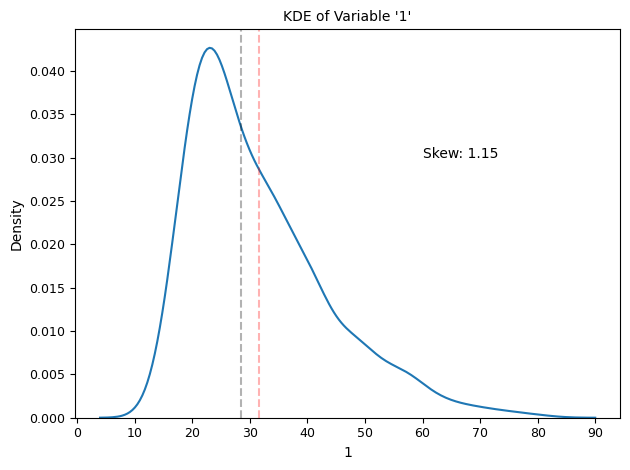

In [5]:
#analyze distributions of numerical variables with missing values -- column "1"
    #cannot use a histogram with float values --> can use a kernel-density plot

#Plot column '1', the mean (red), the median (black)
    #since this column had missing values ("?"), need to convert from objects to floats
ax1 = sns.kdeplot(data_I.iloc[:,1].astype('float'))
ax1.axvline(x=data_I.iloc[:,1].astype('float').mean(), color='red', linestyle='--', alpha=0.3)
ax1.axvline(x=data_I.iloc[:,1].astype('float').median(), color='black', linestyle='--', alpha=0.3)
#annotate the plot with the skew of this variable
ax1.text(60,.03, "Skew: {}".format(round(data_I.iloc[:,1].astype('float').skew(), 2), fontsize=1));

#edit plot details
plt.title("KDE of Variable '1'", fontsize=10)
plt.xticks(ticks=range(0,91,10), fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout();

The plan for handling missing values in numerical variables is to impute with either the mean or median. These two metrics are more appropriate for cetain situations, & the better option can be determined via a variable's distribution & skew. For reference, review the following notes:
- Use the **mean** when:
    - Data is normally distributed
    - Data has skew ~ 0
- Use the **median** when:
    - Data is not normally distributed (skewed), has extreme values & outliers
    - Data has skew !~ 0

Recall that across the whole dataset, six columns have missing values; '0', '1', '3', '4', '5', '6'.
With this information in mind, it can be used in conjunction with the plots above to determine whether the mean/median is more appropriate for imputing missing values in the column '1'. The plot above illustrates a kernel density plot of this variable, which shows the distribution of the values.

The distribution of the variable '1' is notably skewed. Additionally, the skew of this variable, ~ 1.15, is considerably far from zero given the range of values of this variable. As such, the median is the more appropriate metric for imputing missing values in this column.

For the other five non-numerical columns, '0', '3', '4', '5', '6', use the mode to impute the missing values.

In [6]:
#Impute missing values for columns with missing values: "0", "1", "3", "4", "5", "6". Perform this on a new copy of the data
data_II = data_I.copy()

#NUMERICAL VALUES:
#Column "1" - use the median, round to 2 decimals to retain consistency
    #the median already has 2 decimals -- GOOD
    #first, convert the column values to floats, then back to objects
#display(data_II[1].median())
data_II[1] = data_II[1].astype('float')
data_II[1] = data_II[1].fillna(data_II[1].median()).astype('object')

#NON-NUMERICAL VALUES:
#Columns "0", "3", "4", "5", "6" - use the mode
for col in [0,3,4,5,6]:
    data_II[col] = data_II[col].fillna(data_II[col].mode()[0])

#check that data has no missing values -- GOOD
display(data_II.info())
display(data_II[data_II.isin(["?"]).any(axis=1)])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       690 non-null    object 
 1   1       690 non-null    object 
 2   2       690 non-null    float64
 3   3       690 non-null    object 
 4   4       690 non-null    object 
 5   5       690 non-null    object 
 6   6       690 non-null    object 
 7   7       690 non-null    float64
 8   8       690 non-null    object 
 9   9       690 non-null    object 
 10  10      690 non-null    int64  
 11  11      690 non-null    object 
 12  12      690 non-null    int64  
 13  13      690 non-null    object 
dtypes: float64(2), int64(2), object(10)
memory usage: 75.6+ KB


None

,0,1,2,3,4,5,6,7,8,9,10,11,12,13


# Objectives
Use supervised learning techniques to automate the credit card approval process for banks.
- Preproccess the data and apply **supervised** learning techniques to find the best *model* and *parameters* for the job. Save the accuracy score from your best model as a numeric variable, `best_score`. Aim for an accuracy score of at least `0.75`. **The target variable is the last column of the DataFrame.**

**Notes & plan of action:**
- The current, cleaned version of the dataset can be obtained with the variable `data_II`.
- Recall that machine learning techniques from scikit-learn require the data to:
    - have no missing values,
    - be in numeric format,
    - be stored in a numpy array of pandas data frame.
- As surmised previously, the last column ('13') may be the target variable for the purposes of this analysis. If this is the case, & given that this column contains non-numerical values, logistic regression would be an appropriate machine learning technique.
- Given that many of the variables in the dataset have non-numerical, it would be necessary to convert them to numerical values before applying scikit-learn techniques on them. This could be done using `pandas.get_dummies()` or scikit-learn's OneHotEncoder.
- By inspecting the ranges of the numerical variables, they are significantly different, & so their variances are likely to differ significantly as well. Features on far larger scales can disproportionately influence a machine learning model. As such, it would be better if the variances of these features were standardized/normalized. This can be done by applying a StandardScaler to the data before modeling. Note that the data should be split into training & testing sets before performing this operation.

In [7]:
#Encode dummy variables
data_dummies = pd.get_dummies(data_II, drop_first=True)
display(data_dummies.head())

#assign the feature variables -- all columns except the last
X = data_dummies.iloc[:,:-1].values
#assign the target variable -- the last column
y = data_dummies.iloc[:,[-1]].values
display(X.shape, y.shape)

,2,7,10,12,0_b,1_15.17,1_15.75,1_15.83,1_15.92,1_16.0,...,6_j,6_n,6_o,6_v,6_z,8_t,9_t,11_p,11_s,13_-
0,0.000,1.25,1,0,True,False,False,False,False,False,...,False,False,False,True,False,True,True,False,False,False
1,4.460,3.04,6,560,False,False,False,False,False,False,...,False,False,False,False,False,True,True,False,False,False
2,0.500,1.50,0,824,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
3,1.540,3.75,5,3,True,False,False,False,False,False,...,False,False,False,True,False,True,True,False,False,False
4,5.625,1.71,0,0,True,False,False,False,False,False,...,False,False,False,True,False,True,False,False,True,False


(690, 383)

(690, 1)

In [12]:
#split the data into training/testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=10)

#apply a StandardScaler to the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#instantiate a LogReg model w/default parameters
model = LogisticRegression()
#fit the model
model.fit(X_train_scaled, y_train)
#generate predictions
y_pred = model.predict(X_train_scaled)

C:\Users\elija\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1184: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [9]:
#Create a confusion matrix, classification report to evaluate the model
CM = confusion_matrix(y_train, y_pred)
display(CM)
class_rep = classification_report(y_train, y_pred)
display(class_rep)

array([[225,   3],
       [  3, 286]], dtype=int64)

'              precision    recall  f1-score   support\n\n       False       0.99      0.99      0.99       228\n        True       0.99      0.99      0.99       289\n\n    accuracy                           0.99       517\n   macro avg       0.99      0.99      0.99       517\nweighted avg       0.99      0.99      0.99       517\n'

In [10]:
#Perform hyperparameter tuning

#define the grid of values for tol & max_iter
tol = [0.01, 0.001, 0.0001]
max_iter = [100, 150, 200]

#create a dictionary where tol & max_iter are keys & the lists of their values are the corresponding values
param_grid = dict(tol=tol, max_iter=max_iter)

#instantiate GridSearchCV with the required parameters
grid_model = GridSearchCV(estimator=model, param_grid=param_grid, cv=5)

#fit grid_model to the data
grid_model_result = grid_model.fit(X_train_scaled, y_train)

#summarize results
best_train_score, best_train_params = grid_model_result.best_score_, grid_model_result.best_params_
print("Best: %f using %s" % (best_train_score, best_train_params))

#extract the best model & evaluate it on the test set, & assign the specified variable in DataCamp
best_model = grid_model_result.best_estimator_
best_score =  best_model.score(X_test_scaled, y_test)

print("Accuracy of logistic regression classifier: ", best_score)

C:\Users\elija\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1184: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\elija\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1184: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\elija\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1184: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\elija\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1184: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,

Best: 0.806479 using {'max_iter': 100, 'tol': 0.001}
Accuracy of logistic regression classifier:  0.791907514450867


C:\Users\elija\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1184: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\elija\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1184: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Some metrics:
- 225 true negatives & 286 true positives. Three false positives & three false negatives. Of the 517 data points, the model correctly predicted 511 of them.
- Hyperparameter metrics. The best model had:
    - A score of about 0.81,
    - The maximum number of iterations taken for the solvers to converge: 100,
    - Tolerance for stopping criteria: 0.001.
- The accuracy of the logistic regression classifier was about 79.2%.